# **MÓDULO 39 - Exercicio - Aplicando SVM**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros. A mesma que também usamos na tarefa de XGboost!


In [1]:
# Imports para arquivo

import os

# Imports para dados

import numpy as np
import pandas as pd

# Imports para gráficos

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Imports para preprocessamento

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Imports de modelo

from sklearn.svm import SVC

# Imports para resultados

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


- Carregamento da base de dados

In [2]:
# Definindo o caminho

path = ".\\CARRO_CLIENTES.csv"

# Verificando se o caminho existe

if os.path.exists(path):
    print("Caminho encontrado")

else:
    print("Caminho não foi encontrado")

# Definindo a base de dados

df = pd.read_csv(path)

# Verificando resultado

df

Caminho encontrado


,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1


- Remoção da coluna ID

In [3]:
# Removendo a coluna ID

df = df.drop(columns='User ID')

- Verificação dos dados

In [4]:
# Verificando Dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Gender        1000 non-null   object
 1   Age           1000 non-null   int64 
 2   AnnualSalary  1000 non-null   int64 
 3   Purchased     1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB


Obs: Como podemos observar, não há dados faltantes, e só precisamos alterar o tipo de apenas 1 coluna.

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

- Codificação da coluna Gender

In [ ]:
# Instancinado Label Encoder

labele = LabelEncoder()

# Codificando a coluna Gender

df['GenderEncoded'] = labele.fit_transform(df['Gender'])

- Remoção da coluna categórica

In [6]:
# Removendo coluna categórica

df = df.drop(columns='Gender')

# Verificando resultados

df

,Age,AnnualSalary,Purchased,GenderEncoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1
...,...,...,...,...
995,38,59000,0,1
996,47,23500,0,0
997,28,138500,1,0
998,48,134000,1,0


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

- Matriz de correlação

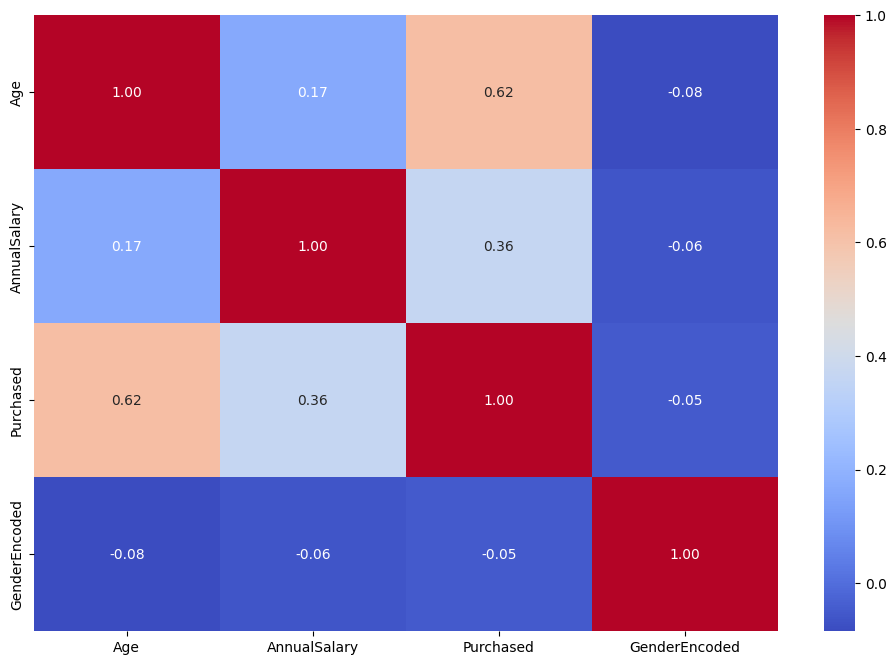

In [ ]:
# Instanciando correlação 

corr_matriz = df.corr()

# Criando o gráfico para a Matriz

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matriz, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

Obs: Olhando a matriz, dá pra perceber bem claramente quais variáveis mais influenciam na decisão de compra. A idade (Age) se destaca com uma correlação de 0.62 com o target — isso é bastante alto, e indica que clientes mais velhos têm uma propensão consideravelmente maior de comprar o carro. Faz sentido quando você pensa: pessoas mais velhas geralmente já têm mais estabilidade financeira e mais necessidade de um veículo próprio.

O salário anual (AnnualSalary) também aparece com correlação relevante (0.36) — afinal, carro é um investimento significativo, e quem ganha mais tem naturalmente mais facilidade pra bancar essa decisão.
Já o gênero (GenderEncoded) praticamente não influencia nada (-0.05), o que sugere que, nessa base pelo menos, homens e mulheres têm comportamentos de compra muito parecidos.

Visando realizar uma breve análise irei fazer dois gráficos para entender melhor como a variável target se relaciona com as outras duas variáveis que mais se correlacionam com ela.

- Age x Purchased

In [8]:
fig = px.box(
    df,
    x="Purchased",
    y="Age",
    color="Purchased",
    labels={"Purchased": "Comprou o carro", "Age": "Idade"}
)
fig.update_xaxes(tickvals=[0, 1], ticktext=["Não comprou", "Comprou"])
fig.update_layout(title="Idade por decisão de compra")
fig.show()

Obs: O gráfico mostra uma separação bastante clara entre os dois grupos: clientes que não compraram o carro têm idade mediana em torno de 35 anos, enquanto os que compraram têm mediana em torno de 50 anos, com pouca sobreposição entre as distribuições. Isso é consistente com a correlação de 0.62 observada na matriz — a mais alta entre as variáveis e o target — e sugere que a idade é um forte indicador da propensão à compra.

- Annual Salary x Purchased

In [9]:
# Criando gráfico

fig = px.box(
    df,
    x="Purchased",
    y="AnnualSalary",
    color="Purchased",
    labels={"Purchased": "Comprou o carro", "AnnualSalary": "Salário anual"}
)
fig.update_xaxes(tickvals=[0, 1], ticktext=["Não comprou", "Comprou"])
fig.update_layout(title="Salário anual por decisão de compra")
fig.show()

Obs: O gráfico mostra que clientes com salário anual maior têm maior propensão a comprar o carro — a mediana de quem não comprou é de aproximadamente R$ 60k, enquanto a de quem comprou é de quase R$ 100k. Esse resultado é coerente com a correlação de 0.36 observada na matriz e faz sentido no contexto: um carro representa um investimento considerável, e maior renda facilita essa decisão. Vale notar que renda baixa não impede a compra — há clientes com salários menores presentes em ambos os grupos —, mas a tendência geral é clara: quanto maior a renda, maior a chance de compra.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

- Separação em X e y

In [10]:
# Separando em X e y

X = df.drop(columns="Purchased")

y = df['Purchased']

# Verificando Resultado

print("Tamanho de X é: ", X.shape)
print("Tamanho de y é ", y.shape)

Tamanho de X é:  (1000, 3)
Tamanho de y é  (1000,)


- Separação em treino e teste

In [11]:
# Separando em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=48)

# Verificando resultado

print("O tamanho de X_train é ", X_train.shape)
print("O tamanho de y_train é ", y_train.shape)
print("O tamanho de X_test é ", X_test.shape)
print("O tamanho de y_test é ", y_test.shape)

O tamanho de X_train é  (800, 3)
O tamanho de y_train é  (800,)
O tamanho de X_test é  (200, 3)
O tamanho de y_test é  (200,)


**Todos passos até aqui já foram realizados no último projeto!**

# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

- Padronização Dados

In [12]:
# Instanciando modelo de padronização

SS = StandardScaler()

# Padronizando dados

X_train_pad = SS.fit_transform(X_train)
X_test_pad = SS.transform(X_test)

- Criação e treinamento do modelo

In [ ]:
# Instanciando modelo

SVC_linear = SVC(kernel='linear', C = 1, random_state=48)

# Treinando modelo

SVC_linear.fit(X_train_pad, y_train)

,C,0.5
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# 6. Realize as previsões para a base de teste e traga a avaliação.

- Previsões e resultados

In [ ]:
# Previsões

y_pred_linear = SVC_linear.predict(X_test_pad)

# Métricas de avaliação

acuracia_linear = accuracy_score(y_test, y_pred_linear)
report_linear = classification_report(y_test, y_pred_linear)
conf_linear = confusion_matrix(y_test, y_pred_linear)

# Resultados

print(acuracia_linear)
print("\n", report_linear, "\n")
print(conf_linear)


0.81
               precision    recall  f1-score   support

           0       0.77      0.93      0.84       109
           1       0.88      0.67      0.76        91

    accuracy                           0.81       200
   macro avg       0.83      0.80      0.80       200
weighted avg       0.82      0.81      0.81       200
 
[[101   8]
 [ 30  61]]


# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

- Criação e treinamento do modelo

In [ ]:
# Instanciando modelo

SVC_poly = SVC(
    kernel = 'poly',
    degree= 3, 
    C = 1,  
    gamma = 'scale',  # calculado automaticamente
    coef0 = 1,        # ajuda o kernel poly a capturar termos de menor grau
    random_state = 48)        

# Treinando modelo

SVC_poly.fit(X_train_pad, y_train)


,C,1
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,1
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


- Previsão e resultados

In [16]:
# Previsões

y_pred_poly = SVC_poly.predict(X_test_pad)

# Métricas de avaliação

acuracia_poly = accuracy_score(y_test, y_pred_poly)
report_poly = classification_report(y_test, y_pred_poly)
conf_poly = confusion_matrix(y_test, y_pred_poly)

# Verificando resultados

print(acuracia_poly)
print("\n", report_poly,"\n")
print(conf_poly)

0.885

               precision    recall  f1-score   support

           0       0.88      0.91      0.90       109
           1       0.89      0.86      0.87        91

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200
 

[[99 10]
 [13 78]]


# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

Resposta: Entre os dois kernels do SVM, o modelo polinomial (88.5%) superou o linear (81.5%) por uma margem pequena mas consistente. Isso sugere que, apesar de existir uma correlação linear relevante — especialmente da idade com a variável target (0.62) —, os dados apresentam alguns padrões que fogem de uma separação puramente linear. O kernel polinomial conseguiu capturar essas nuances com mais precisão, traçando uma fronteira de decisão ligeiramente mais flexível que a reta do kernel linear.

No entanto, o modelo que se saiu melhor entre todos foi o XGBoost, com 90% de acurácia. Isso faz sentido quando a gente olha pra natureza dos dois algoritmos: o SVM, independente do kernel, trabalha com um único hiperplano pra separar as classes. Já o XGBoost é um modelo ensemble — ele constrói centenas de árvores de decisão sequencialmente, onde cada árvore corrige os erros da anterior, chegando a um resultado final muito mais refinado. Essa capacidade de iterar e se corrigir várias vezes permite que o XGBoost capture padrões mais complexos e variações nos dados que um único hiperplano dificilmente conseguiria representar. Por isso, nessa base, ele se mostrou o modelo mais adequado.